# 08 Your Own Question: Capstone Project
**Tutorial:** Building Geospatial Data Cubes for Earth Data Science  
**Focus:** Pine Ridge and Oceti Sakowin Tribal Nations  
**Prerequisites:** Notebooks 00–07  

## What This Notebook Is
This is not a tutorial notebook. There are no step-by-step instructions,
no correct answers, and no single visualization to produce.
This is where you apply everything you have built to a question you
care about.

## The Assignment
- Define one question about land, environment, or climate. 
- Build a data cube to answer it. 
- Produce one visualization that communicates the answer to a non-technical audience.

Your question should:
- Be specific enough to answer with the data available
- Be grounded in something that matters to a Tribal community
- Require at least two of the analytical patterns from notebook 06

Your visualization should:
- Be readable without the code
- Have a title that states the finding, not just the topic
- Include the data source and the Tribal Nation it describes

## Example Questions
These are starting points. Your question should come from your own
knowledge and interests, not from this list.

**Vegetation and land health:**
- Has growing season vegetation condition on the Pine Ridge or Rosebud 
  Reservation improved or declined over the past 24 years?
- Which months show the most year-to-year variability in NDVI
  on Pine Ridge and does drought affect early season or
  late season growth more?
- How different is the NDVI trend on Standing Rock compared
  to Pine Ridge? Do the two Nations respond to drought years similarly?

**Climate:**
- How many growing season days on Pine Ridge exceeded 95°F
  in the hottest year on record? How does that compare to the
  coolest year?
- Is the growing season getting longer (earlier green-up,
  later senescence) on any SD Tribal Nation?
- Which Oceti Sakowin Tribal Nation experienced the most consecutive
  dry years between 2000 and 2023?

**Cross-variable questions:**
- In drought years on Pine Ridge, does NDVI recover faster
  when the following spring is wet?
- Is the relationship between precipitation and NDVI
  different on the eastern Oceti Sakowin Tribal Nations (Flandreau,
  Lake Traverse) than on the western ones (Pine Ridge, Rosebud)?

## Data Available to You
All data is available through the functions in `cube_utils.py`:

| Data | Function | Variables |
|---|---|---|
| MODIS NDVI | `fetch_ndvi_timeseries()` | NDVI (2000–present) |
| gridMET temperature | `fetch_gridmet_point(variable="tmmx")` | Max temp (K) |
| gridMET precipitation | `fetch_gridmet_point(variable="pr")` | Precip (mm) |
| gridMET min temp | `fetch_gridmet_point(variable="tmmn")` | Min temp (K) |
| gridMET wind | `fetch_gridmet_point(variable="vs")` | Wind speed (m/s) |
| gridMET humidity | `fetch_gridmet_point(variable="rmax")` | Max RH (%) |
| Tribal boundaries | `load_sd_tribal_boundaries()` | 8 SD Nations |
| Pine Ridge boundary | `load_pine_ridge_boundary()` | Polygon |

## Data Sovereignty Reminder
Before you start, answer these questions:

1. **Whose land does your analysis describe?**
   Name the specific Tribal Nation(s).

2. **Who benefits from this analysis?**
   How would this analysis be useful to that community?

3. **What can't this data show?**
   What ground-level knowledge would be needed to fully
   interpret your results?

Write your answers in the markdown cell below before you write any code.



## My Question

*(Replace this text with your own question and answers.)*

**My question:** 

**Whose land does this analysis describe?**

**Who benefits from this analysis?**

**What can this data NOT show?**

In [1]:
# Imports
import sys
from pathlib import Path

REPO_ROOT = Path().resolve().parent
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

import warnings
import numpy as np
import pandas as pd
import xarray as xr
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from scipy import stats

from src.cube_utils import (
    load_pine_ridge_boundary,
    load_sd_tribal_boundaries,
    fetch_ndvi_timeseries,
    fetch_gridmet_point,
    timeseries_to_dataarray,
    compute_growing_season_mean,
    compute_anomaly,
    CACHE_DIR,
    PINE_RIDGE_BBOX,
)

warnings.filterwarnings("ignore", category=FutureWarning)
%matplotlib inline

def despine(ax):
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

# Your parameters
# Change these to match your question

MY_NATION   = "Oglala Lakota"   # Which Tribal Nation are you analyzing?
MY_LAT      = 43.35             # Centroid latitude
MY_LON      = -102.09           # Centroid longitude
START_YEAR  = 2000
END_YEAR    = 2023

print(f"Capstone: {MY_NATION}")
print(f"Location: {MY_LAT}°N, {MY_LON}°W")
print(f"Period  : {START_YEAR}–{END_YEAR}")

Capstone: Oglala Lakota
Location: 43.35°N, -102.09°W
Period  : 2000–2023


---
## Starter: Load Your Data

The cells below load NDVI and temperature for the location you specified.
Add or replace variables as needed for your question.

In [2]:
# Load NDVI
ndvi_df = fetch_ndvi_timeseries(
    lat=MY_LAT, lon=MY_LON,
    start_year=START_YEAR, end_year=END_YEAR,
    site_name=MY_NATION,
)
ndvi_da = timeseries_to_dataarray(
    ndvi_df, name="ndvi",
    attrs={
        "long_name":    "NDVI",
        "source":       "MODIS MOD13Q1",
        "tk_community": MY_NATION,
    }
)
print(f"NDVI loaded: {len(ndvi_da)} observations")

NDVI loaded: 549 observations


In [3]:
# Load climate variables (add/remove as needed)
tmax_df = fetch_gridmet_point(
    lat=MY_LAT, lon=MY_LON,
    variable="tmmx",
    start_year=START_YEAR, end_year=END_YEAR,
    site_name=MY_NATION,
)
tmax_df["tmmx"] = (tmax_df["tmmx"] - 273.15) * 9/5 + 32  # K → °F

precip_df = fetch_gridmet_point(
    lat=MY_LAT, lon=MY_LON,
    variable="pr",
    start_year=START_YEAR, end_year=END_YEAR,
    site_name=MY_NATION,
)

tmax_da   = timeseries_to_dataarray(tmax_df,   date_col="date", value_col="tmmx",  name="tmax_f")
precip_da = timeseries_to_dataarray(precip_df, date_col="date", value_col="pr",    name="precip_mm")

print(f"Temperature loaded: {len(tmax_da)} daily observations")
print(f"Precipitation loaded: {len(precip_da)} daily observations")

  Cached 8766 daily observations → gridmet_tmmx_oglala_lakota_2000_2023.csv
  Cached 8766 daily observations → gridmet_pr_oglala_lakota_2000_2023.csv
Temperature loaded: 8766 daily observations
Precipitation loaded: 8766 daily observations


In [10]:
# Build your cube
# Resample to monthly and align time axes
ndvi_monthly   = ndvi_da.resample(time="MS").mean()
tmax_monthly   = tmax_da.resample(time="MS").mean()
precip_monthly = precip_da.resample(time="MS").sum()

t0 = max(
    pd.Timestamp(ndvi_monthly.time.values[0]),
    pd.Timestamp(tmax_monthly.time.values[0]),
    pd.Timestamp(precip_monthly.time.values[0]),
)
t1 = min(
    pd.Timestamp(ndvi_monthly.time.values[-1]),
    pd.Timestamp(tmax_monthly.time.values[-1]),
    pd.Timestamp(precip_monthly.time.values[-1]),
)

my_cube = xr.Dataset(
    data_vars={
        "ndvi":      ndvi_monthly.sel(time=slice(t0, t1)),
        "tmax_f":    tmax_monthly.sel(time=slice(t0, t1)),
        "precip_mm": precip_monthly.sel(time=slice(t0, t1)),
    },
    attrs={
        "title":        f"Environmental Data Cube for {MY_NATION}",
        "tk_community": MY_NATION,
        "tk_usage":     "Non-commercial environmental research",
        "ieee_2890":    "https://standards.ieee.org/ieee/2890/10318/",
    }
)

print("Your cube:")
print(my_cube)

Your cube:
<xarray.Dataset> Size: 9kB
Dimensions:    (time: 287)
Coordinates:
  * time       (time) datetime64[us] 2kB 2000-02-01 2000-03-01 ... 2023-12-01
Data variables:
    ndvi       (time) float64 2kB 0.2375 0.2382 0.2788 ... 0.4523 0.3669 0.2874
    tmax_f     (time) float64 2kB 46.74 54.24 60.15 72.12 ... 60.32 53.92 44.91
    precip_mm  (time) float64 2kB 20.8 55.1 108.3 63.2 ... 54.8 95.5 4.1 20.9
Attributes:
    title:         Environmental Data Cube for Oglala Lakota
    tk_community:  Oglala Lakota
    tk_usage:      Non-commercial environmental research
    ieee_2890:     https://standards.ieee.org/ieee/2890/10318/


---
## Your Analysis

Use the cells below to build your analysis. Add as many cells as you need.
The scaffold cells are suggestions, delete or replace them to fit your project.

**Reminder of available patterns (from notebook 06):**
- Anomaly: `compute_anomaly(da)`
- Growing season mean: `compute_growing_season_mean(da, months=[5,6,7,8,9])`
- Trend: `scipy.stats.theilslopes(values, years)`
- Composite: `.sel(time=...).groupby("time.month").mean()`
- Correlation: `scipy.stats.pearsonr(x, y)`
- Percentile: `scipy.stats.percentileofscore(all_values, this_value)`

In [ ]:
# Your analysis: add your analysis here

GROWING_MONTHS = [5, 6, 7, 8, 9]

ndvi_annual   = compute_growing_season_mean(my_cube["ndvi"],   GROWING_MONTHS)
tmax_annual   = compute_growing_season_mean(my_cube["tmax_f"], GROWING_MONTHS)
precip_annual = (
    my_cube["precip_mm"]
    .sel(time=my_cube.time.dt.month.isin(GROWING_MONTHS))
    .groupby("time.year")
    .sum()
)

years = ndvi_annual.year.values.astype(int)

print(f"Annual growing season data ready: {len(years)} years")
print(f"NDVI range: {float(ndvi_annual.min()):.3f} – {float(ndvi_annual.max()):.3f}")

Annual growing season data ready: 24 years
NDVI range: 0.371 – 0.613


In [ ]:
# Your second analysis: add your analysis here


In [ ]:
# Your third analysis: add your analysis here


## Your Final Visualization
Produce one visualization that answers your question for a non-technical
audience. Requirements:

- **Title states the finding**, not just the topic.
  OK: "Growing Season NDVI on Pine Ridge"
  Better: "Vegetation Condition on Pine Ridge Has Declined in 6 of the Last 10 Years"

- **Subtitle or caption** identifies the data source and Tribal Nation.

- **No unexplained acronyms.** NDVI should be labeled as
  "Vegetation Condition (NDVI)" or similar.

- **Saved to outputs/figures/** so it can be shared.

Saved: C:\Users\gekek\Documents\OLC_DC_tutorial\outputs\figures\capstone_oglala_lakota.png


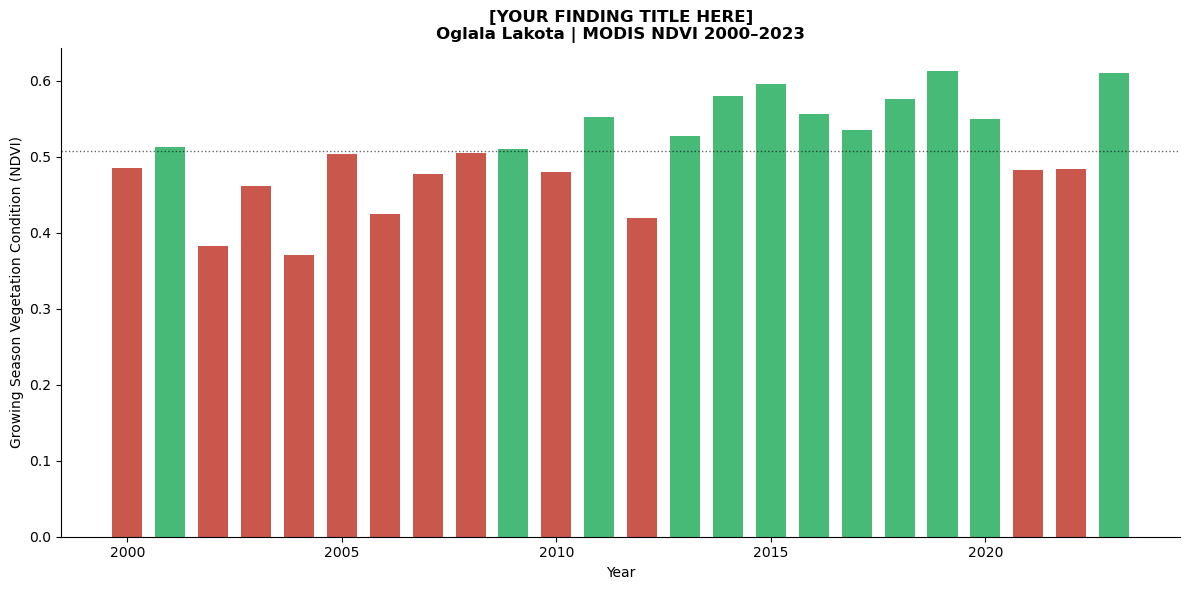

In [8]:
# Your final visualization
fig, ax = plt.subplots(figsize=(12, 6))

# Your visualization code here
# Scaffold: annual NDVI bar chart (replace with your own)
colors = [
    "#C0392B" if v < float(ndvi_annual.mean()) else "#27AE60"
    for v in ndvi_annual.values
]
ax.bar(years, ndvi_annual.values, color=colors, alpha=0.85, width=0.7)
ax.axhline(float(ndvi_annual.mean()), color="black",
           linewidth=1, linestyle=":", alpha=0.6)

# Replace these with your own title and labels
ax.set_title(
    f"[YOUR FINDING TITLE HERE]\n"
    f"{MY_NATION} | MODIS NDVI {START_YEAR}–{END_YEAR}",
    fontsize=12, fontweight="bold",
)
ax.set_xlabel("Year", fontsize=10)
ax.set_ylabel("Growing Season Vegetation Condition (NDVI)", fontsize=10)
despine(ax)
plt.tight_layout()

# Save
fig_dir = REPO_ROOT/"outputs"/"figures"
fig_dir.mkdir(parents=True, exist_ok=True)
fig_path = fig_dir / f"capstone_{MY_NATION.replace(' ', '_').lower()}.png"
fig.savefig(fig_path, dpi=150, bbox_inches="tight")
print(f"Saved: {fig_path}")
plt.show()

## Reflection
Answer these questions in the cell below before you consider this
notebook complete.

**1. What does your visualization show?**

*(Write 2–3 sentences describing what a non-technical reader
should take away from your visualization.)*


---

**2. What would a land manager or community member need to know
to interpret this correctly?**

*(What context, caveats, or ground-level knowledge would they need?)*


---

**3. What would you do next if you had more time?**

*(More data? Different analysis? A conversation with someone
who knows this land?)*


---

**4. What did building this cube teach you that you didn't
expect to learn?**



## Tutorial Complete
You have built data cubes from real satellite and climate data,
applied the core analysis patterns of Earth data science, and
produced a visualization grounded in the land and communities
of South Dakota.

The tools you used in this tutorial are the same tools used by researchers at NASA, 
NOAA, university labs, and Tribal environmental programs across
the country. The difference is what you bring to the analysis:
knowledge of the land, relationships with the communities it
describes, and a responsibility to use these tools in ways that
serve those communities.

## What Comes Next
**If you want to go deeper on Earth data science:**
- Earth Lab Earth Data Science Textbook: https://www.earthdatascience.org/
- Project Pythia (Earth system science with Python): https://projectpythia.org/
- NASA Earthdata tutorials: https://www.earthdata.nasa.gov/learn/tutorials

**If you want to go deeper on data sovereignty:**
- OCAP® Training: https://fnigc.ca/ocap-training/
- CARE Principles: https://www.gida-global.org/care
- Collaboratory for Indigenous Data Governance: https://indigenousdatalab.org/
- Local Contexts: https://localcontexts.org/

**If you want to apply these tools at your Tribal Nation or college:**
- USDA ReConnect Program (rural broadband and digital infrastructure)
- BIA Tribal Climate Resilience Program
- NOAA Tribal Climate Science Grants
- NSF Tribal Colleges and Universities Program (TCUP)